# Прогнозирование сроков выполнения задач

## Описание проекта

Проект направлен на повышение точности планирования задач и прогнозирования сроков их выполнения. В настоящий момент команды часто недооценивают или переоценивают трудоемкость задач, что снижает надежность обещаний заказчикам и бизнесу. Решение предполагает сбор исторических данных по задачам, обучение ML-модели для предсказания ETA (фактического времени закрытия) и визуализацию систематических отклонений в оценках команд.

## Подготовка рабочей среды

**Листинг 2.1.** Импорт библиотек

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from phik.report import plot_correlation_matrix
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_absolute_error, median_absolute_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor

**Листинг 2.2** Необходимые настройки

In [8]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Анализ данных

**Листинг 3.1** Загрузка файла с данными

In [11]:
df = pd.read_excel('data.xlsx')

**Листинг 3.2** Вывод выборки из пяти строк

In [13]:
df.sample(5)

,Приоритет,Тип,Ключ,Статус,Резолюция,Создано,Дата завершения,Теги,Original Story Points,Длина описания,Длина названия
278,Средний,Задача,CARGODEV-55830,Закрыт,Решен,2025-01-13 18:53:47.818,2025-01-16 03:00:00,"ru, cis, int, perspective_research, motion_model",3.0,0,55
43,Средний,Technical Task,CARGODEV-55299,Закрыт,Решен,2024-12-23 09:54:19.622,2025-01-09 03:00:00,"lk_web, cargo_web, cargo_planned",1.0,170,81
7197,Средний,Задача,CARGODEV-65383,Закрыт,Решен,2025-07-14 12:52:11.422,2025-08-25 03:00:00,cargo_c2c,5.0,344,64
8327,Средний,Задача,CARGODEV-68124,Закрыт,Решен,2025-08-27 18:28:47.992,2025-09-23 03:00:00,cargo_b2b,6.0,303,67
13170,Средний,Technical Task,CARGODEV-77436,Закрыт,Решен,2026-02-17 13:38:54.208,2026-02-20 03:00:00,united_dispatch,1.0,89,32


**Листинг 3.3** Вывод основной информации

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15344 entries, 0 to 15343
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Приоритет              15344 non-null  object        
 1   Тип                    15344 non-null  object        
 2   Ключ                   15344 non-null  object        
 3   Статус                 15344 non-null  object        
 4   Резолюция              15344 non-null  object        
 5   Создано                15344 non-null  datetime64[ns]
 6   Дата завершения        15344 non-null  datetime64[ns]
 7   Теги                   15127 non-null  object        
 8   Original Story Points  15152 non-null  float64       
 9   Длина описания         15344 non-null  int64         
 10  Длина названия         15344 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(6)
memory usage: 1.3+ MB


**Описание данных**

  - `Приоритет` — Приоритет задачи;
  - `Тип` — Тип задачи;
  - `Ключ` — Уникальный идентификатор задачи;
  - `Статус` — Текущий или финальный статус задачи;
  - `Резолюция` — Результат завершения задачи;
  - `Создано` — Дата и время создания задачи;
  - `Дата завершения` — Дата и время завершения задачи;
  - `Теги` — Теги задачи;
  - `Original Story Points` — Первоначальная оценка трудоемкости задачи в story points;
  - `Длина описания` — Длина описания задачи;
  - `Длина названия` — Длина названия задачи.

В результате первичного анализа было установлено, что датасет содержит 15344 записи и 11 признаков. В данных присутствуют как категориальные признаки, так и числовые признаки. Также были выявлены пропущенные значения в колонках Теги и Original Story Points, что требует дополнительной обработки перед построением модели.

## Предобработка данных

**Листинг 4.1** Ренейминг колонок

In [20]:
df = df.rename(columns={
    'Приоритет': 'priority',
    'Тип': 'type',
    'Ключ': 'key',
    'Статус': 'status',
    'Резолюция': 'resolution',
    'Создано': 'created_at',
    'Дата завершения': 'completed_at',
    'Теги': 'tags',
    'Original Story Points': 'story_points',
    'Длина описания': 'description_length',
    'Длина названия': 'title_length'
})

**Листинг 4.2** Вывод количества пропущенных значений

In [22]:
df.isna().sum()

priority                0
type                    0
key                     0
status                  0
resolution              0
created_at              0
completed_at            0
tags                  217
story_points          192
description_length      0
title_length            0
dtype: int64

**Листинг 4.3** Проверка явных дубликатов

In [24]:
df.duplicated().sum()

0

**Листинг 4.4** Создание целевого признака

In [26]:
df['eta_hours'] = (df['completed_at'] - df['created_at']).dt.total_seconds() / 3600
df['eta_days'] = df['eta_hours'] / 24

**Листинг 4.5** Анализ распределения целевого признака

Минимум часов: -492.9930425
Медиана часов: 272.5003922222222
Среднее часов: 685.1132978181301
95% квантиль: 2506.428411486107
99% квантиль: 6986.875357161091
Максимум часов: 30829.655284722223


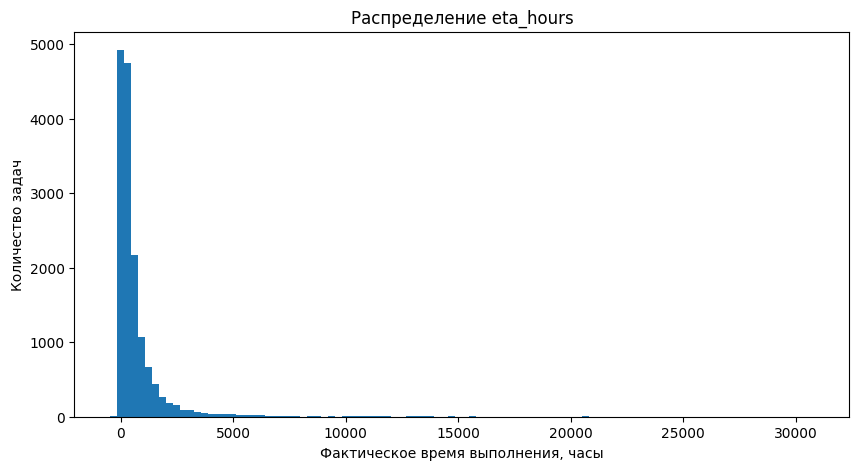

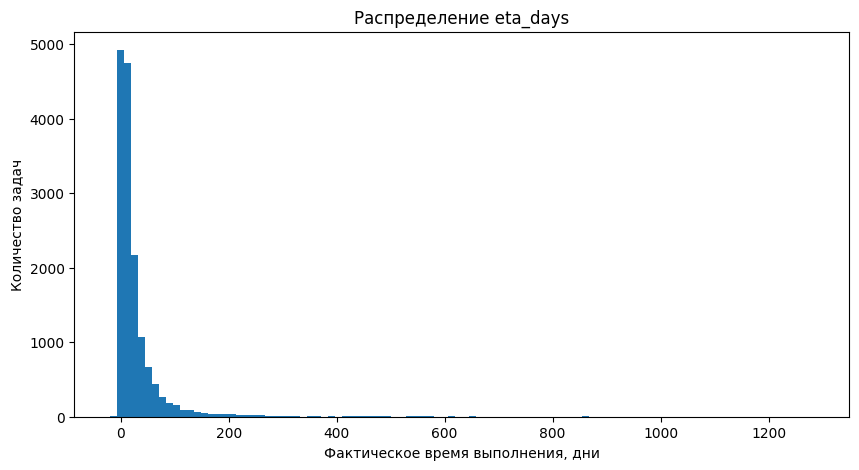

In [28]:
df['eta_hours'].describe(percentiles=[
    0.5,
    0.75,
    0.9,
    0.95,
    0.99
])

print('Минимум часов:', df['eta_hours'].min())
print('Медиана часов:', df['eta_hours'].median())
print('Среднее часов:', df['eta_hours'].mean())
print('95% квантиль:', df['eta_hours'].quantile(0.95))
print('99% квантиль:', df['eta_hours'].quantile(0.99))
print('Максимум часов:', df['eta_hours'].max())

plt.figure(figsize=(10, 5))
plt.hist(df['eta_hours'], bins=100)
plt.xlabel('Фактическое время выполнения, часы')
plt.ylabel('Количество задач')
plt.title('Распределение eta_hours')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df['eta_days'], bins=100)
plt.xlabel('Фактическое время выполнения, дни')
plt.ylabel('Количество задач')
plt.title('Распределение eta_days')
plt.show()

**Листинг 4.6** Ограничение выборки типовыми задачами

In [30]:
upper_limit = 45 * 24

df_model = df[
    (df['eta_hours'] >= 0) &
    (df['eta_hours'] <= upper_limit)
].copy()

print('Размер до удаления выбросов:', df.shape)
print('Размер после удаления выбросов:', df_model.shape)

Размер до удаления выбросов: (15344, 13)
Размер после удаления выбросов: (12237, 13)


**Листинг 4.7** Удаление некорректных строк

In [33]:
df_model = df_model.dropna(subset=['created_at', 'completed_at', 'eta_hours'])

**Листинг 4.8** Создание логарифмированного целевого признака

In [35]:
df_model['eta_hours_log'] = np.log1p(df_model['eta_hours'])

**Листинг 4.9** Создание новых признаков и обработка пропусков

In [37]:
df_model['created_year'] = df_model['created_at'].dt.year
df_model['created_month'] = df_model['created_at'].dt.month
df_model['created_day'] = df_model['created_at'].dt.day
df_model['created_dayofweek'] = df_model['created_at'].dt.dayofweek
df_model['created_hour'] = df_model['created_at'].dt.hour
df_model['is_created_weekend'] = df_model['created_dayofweek'].isin([5, 6]).astype(int)

df_model['tags'] = df_model['tags'].fillna('unknown')
df_model['tags_count'] = df_model['tags'].apply(
    lambda x: 0 if x == 'unknown' else len(str(x).split(','))
)

tags_series = df_model['tags'].fillna('unknown').astype(str)
all_tags = (
    tags_series
    .str.split(',')
    .explode()
    .str.strip()
)
top_tags = (
    all_tags[all_tags != 'unknown']
    .value_counts()
    .head(20)
    .index
)
for tag in top_tags:
    col_name = 'tag_' + tag.replace(' ', '_').replace('-', '_')
    df_model[col_name] = tags_series.apply(
        lambda x: int(tag in [t.strip() for t in x.split(',')])
    )

df_model['has_description'] = (df_model['description_length'] > 0).astype(int)
df_model['has_story_points'] = df_model['story_points'].notna().astype(int)
df_model['story_points'] = df_model['story_points'].fillna(df_model['story_points'].median())
df_model['story_points_group'] = pd.cut(
    df_model['story_points'],
    bins=[-0.01, 0.5, 1, 2, 3, 5, 8, np.inf],
    labels=[
        'very_small',
        'small',
        'medium_1',
        'medium_2',
        'large',
        'very_large',
        'extreme'
    ]
)

df_model['eta_per_story_point'] = df_model['eta_hours'] / (df_model['story_points'] + 1)
df_model['planning_deviation'] = df_model['eta_hours'] - df_model['story_points']

На этапе предобработки были переименованы колонки, обработаны пропущенные значения, проверены дубликаты и создан целевой признак eta_hours, отражающий фактическое время выполнения задачи в часах. Также были сформированы дополнительные признаки на основе даты создания задачи, тегов, длины описания и наличия оценки story points. Эти признаки могут быть использованы для дальнейшего анализа и обучения модели.

## Корреляционный анализ данных

**Листинг 5.1** Корреляционная матрица

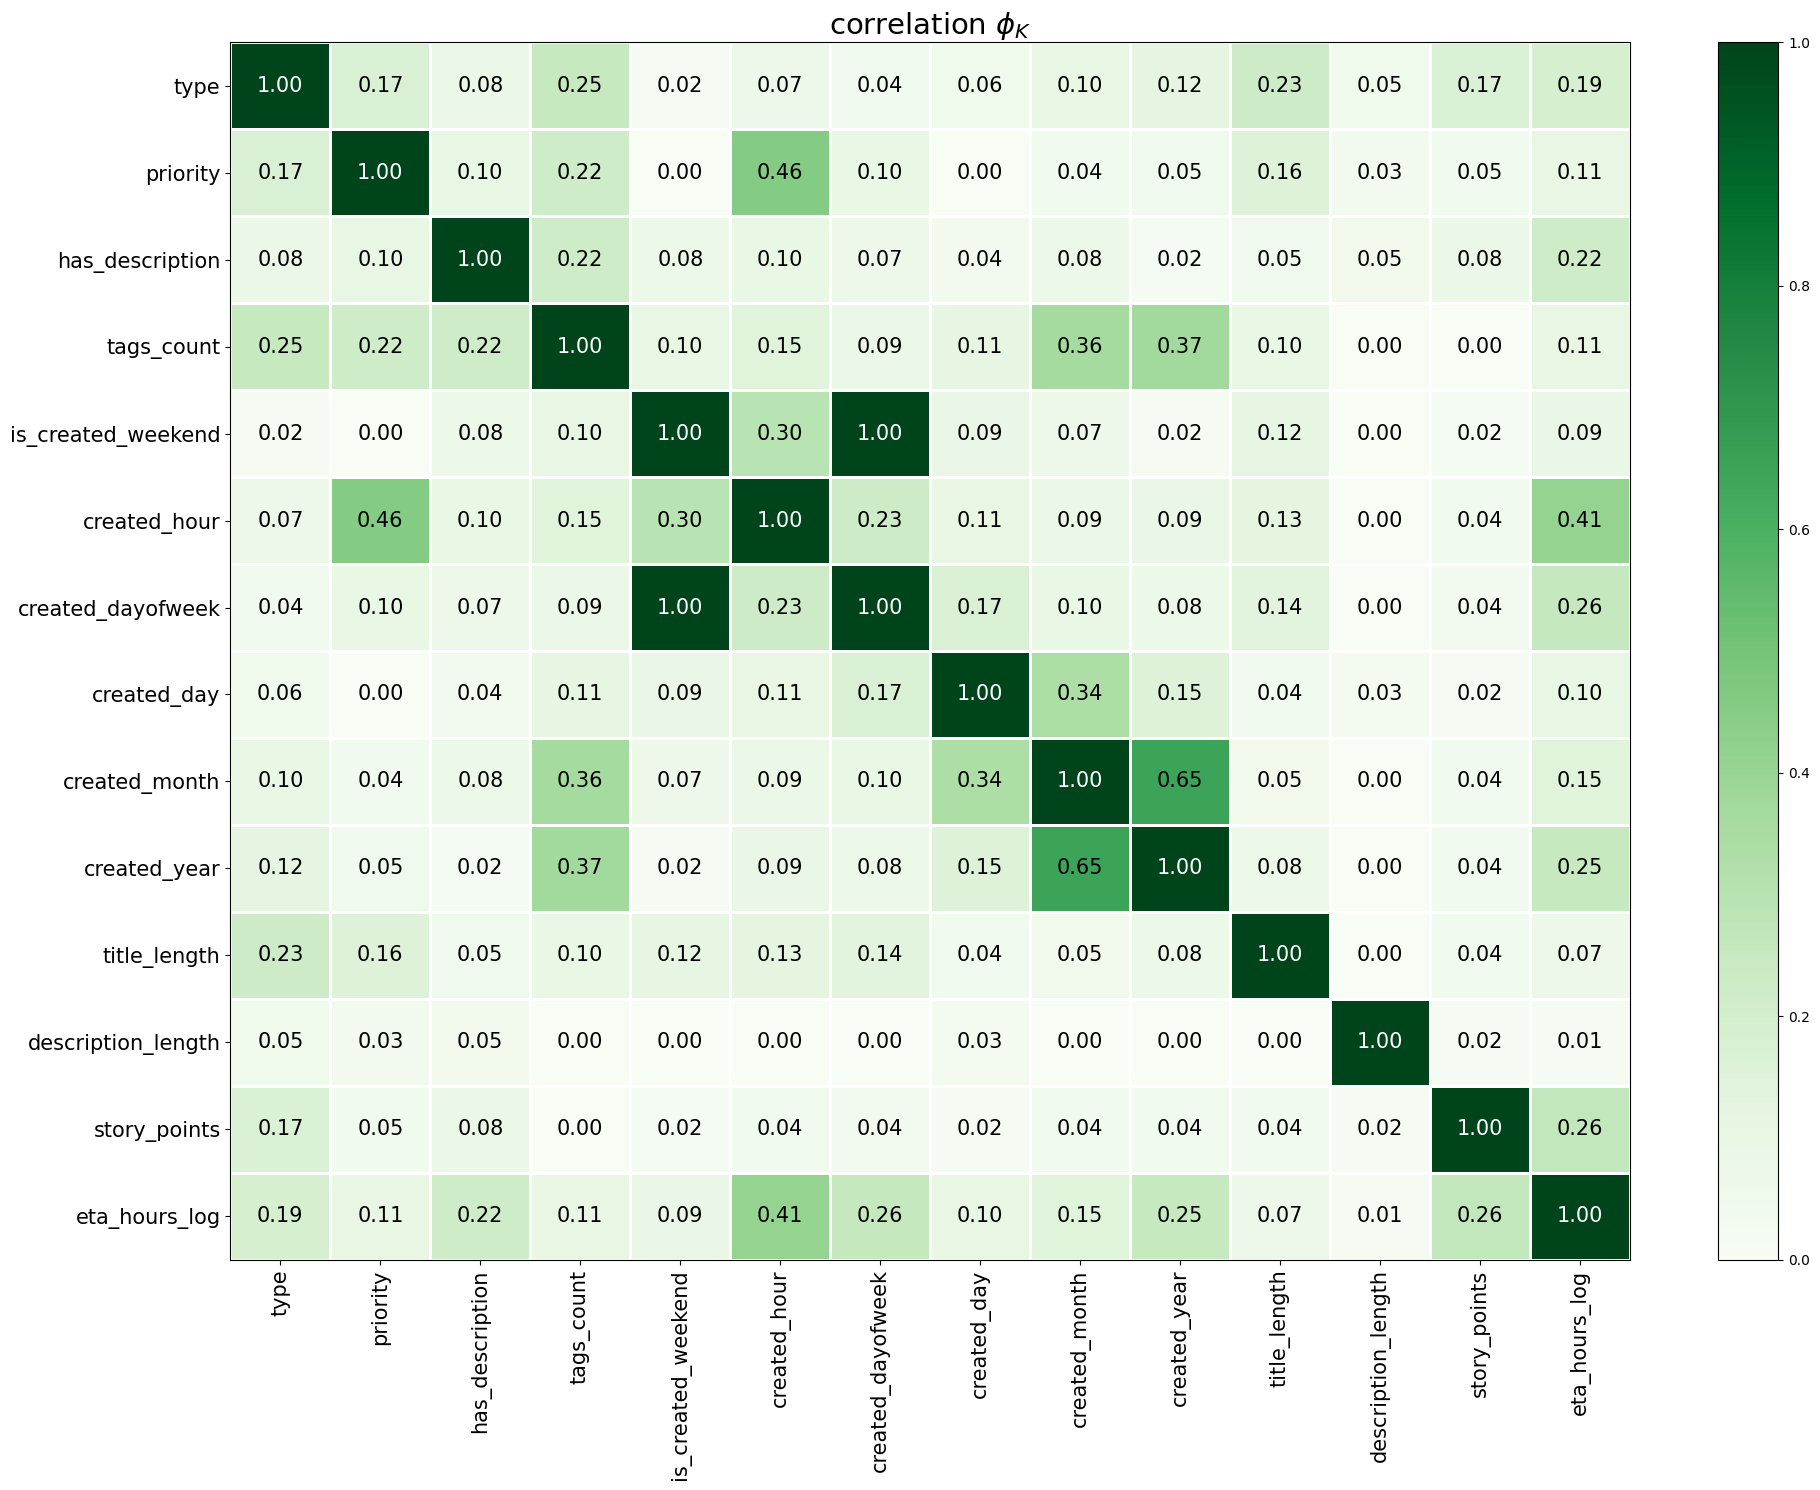

In [41]:
corr_columns = [
    'eta_hours_log',
    'story_points',
    'description_length',
    'title_length',
    'created_year',
    'created_month',
    'created_day',
    'created_dayofweek',
    'created_hour',
    'is_created_weekend',
    'tags_count',
    'has_description',
    'priority',
    'type'
]

df_corr = df_model[corr_columns].copy()

constant_cols = df_corr.columns[df_corr.nunique(dropna=False) <= 1]

df_corr = df_corr.drop(columns=constant_cols)

interval_columns = [
    'eta_hours_log',
    'story_points',
    'description_length',
    'title_length',
    'created_year',
    'created_month',
    'created_day',
    'created_dayofweek',
    'created_hour',
    'is_created_weekend',
    'tags_count',
    'has_description'
]

phik_matrix = df_corr.phik_matrix(interval_cols=interval_columns)
mask = np.triu(np.ones_like(phik_matrix, dtype=bool))
plot_correlation_matrix(
    phik_matrix.values,
    x_labels=phik_matrix.columns,
    y_labels=phik_matrix.index,
    vmin=0,
    vmax=1,
    color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

Корреляционный анализ позволил оценить взаимосвязи между числовыми и категориальными признаками. Наиболее заметная связь наблюдается между eta_hours_log и временными признаками, особенно created_hour. Также определенную связь с фактическим временем выполнения имеют type, has_description и story_points. При этом признаки eta_per_story_point и planning_deviation не должны использоваться при обучении модели, так как они рассчитываются на основе целевого признака и могут привести к утечке данных.

## Подготовка данных

**Листинг 6.1** Выбор признаков и целевой переменной

In [45]:
target = 'eta_hours_log'

columns_to_drop = [
    'eta_hours',
    'eta_hours_log',
    'eta_days',
    'completed_at',
    'created_at',
    'key',
    'status',
    'resolution',
    'tags',
    'eta_per_story_point',
    'planning_deviation'
]

X = df_model.drop(columns=columns_to_drop)
y = df_model[target]

print('Размер матрицы признаков X:', X.shape)
print('Размер целевого признака y:', y.shape)

X.head()

Размер матрицы признаков X: (12237, 35)
Размер целевого признака y: (12237,)


,priority,type,story_points,description_length,title_length,created_year,created_month,created_day,created_dayofweek,created_hour,is_created_weekend,tags_count,tag_cargo_web,tag_udp,tag_ru,tag_cis,tag_int,tag_complete,tag_courier_product,tag_cargo_c2c,tag_united_dispatch,tag_dragon_infra,tag_cargo_b2b,tag_cargo_pricing,tag_cargo_finance,tag_QPlanned,tag_deli_front_infra,tag_cargo_planned,tag_epic,tag_motion_model,tag_cargo_support,tag_udp_ndd,has_description,has_story_points,story_points_group
0,Средний,Technical Task,6.0,624,35,2024,12,11,2,23,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,very_large
1,Средний,Technical Task,1.0,0,26,2024,12,23,0,20,0,5,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,small
2,Средний,Ошибка,2.0,555,64,2024,12,25,2,21,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,medium_1
14,Средний,Задача,2.0,0,31,2024,11,26,1,16,0,6,1,0,1,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,medium_1
15,Средний,Задача,3.0,345,77,2024,12,6,4,13,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,medium_2


**Листинг 6.2** Разделение признаков на OHE, ORD и NUM

In [47]:
ohe_columns = [
    'type',
    'story_points_group'
]

ord_columns = [
    'priority'
]

num_columns = [
    'story_points',
    'description_length',
    'title_length',
    'created_year',
    'created_month',
    'created_day',
    'created_dayofweek',
    'created_hour',
    'is_created_weekend',
    'tags_count',
    'has_description',
    'has_story_points'
]

tag_columns = [
    col for col in X.columns
    if col.startswith('tag_')
]

num_columns = num_columns + tag_columns

**Листинг 6.3** Разделение данных на обучающую и тестовую выборки

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Размер X_train:', X_train.shape)
print('Размер X_test:', X_test.shape)
print('Размер y_train:', y_train.shape)
print('Размер y_test:', y_test.shape)

Размер X_train: (9789, 35)
Размер X_test: (2448, 35)
Размер y_train: (9789,)
Размер y_test: (2448,)


**Листинг 6.4** OHE pipeline

In [51]:
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe',
            SimpleImputer(
                missing_values=np.nan,
                strategy='most_frequent'
            )
        ),
        (
            'ohe',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore',
                sparse_output=False
            )
        )
    ]
)

**Листинг 6.5** Функция замены значений

In [53]:
def replace_values(data):
    data = data.copy()

    priority_mapping = {
        'Низкий': 'low',
        'Средний': 'medium',
        'Высокий': 'high',
        'Низкий приоритет': 'low',
        'Средний приоритет': 'medium',
        'Высокий приоритет': 'high'
    }

    if 'priority' in data.columns:
        data['priority'] = data['priority'].replace(priority_mapping)

    return data

**Листинг 6.6** ORD pipeline

In [55]:
ord_pipe = Pipeline(
    [
        (
            'replace_values',
            FunctionTransformer(replace_values)
        ),
        (
            'simpleImputer_before_ord',
            SimpleImputer(
                missing_values=np.nan,
                strategy='most_frequent'
            )
        ),
        (
            'ord',
            OrdinalEncoder(
                categories=[
                    ['low', 'medium', 'high']
                ],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan
            )
        ),
        (
            'simpleImputer_after_ord',
            SimpleImputer(
                missing_values=np.nan,
                strategy='most_frequent'
            )
        )
    ]
)

**Листинг 6.7** Общий пайплайн предобработки

In [57]:
data_preprocessor_pipe = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='drop'
)

**Листинг 6.8** Финальный пайплайн

In [59]:
final_pipe = Pipeline(
    [
        ('preprocessor', data_preprocessor_pipe),
        ('models', LinearRegression())
    ]
)

На этапе подготовки данных признаки были разделены на три группы: числовые, категориальные номинальные и категориальные порядковые. Для номинальных признаков использовалось One-Hot Encoding, так как между их значениями отсутствует естественный порядок. Для порядкового признака priority использовалось Ordinal Encoding, поскольку значения приоритета можно упорядочить от низкого к высокому. Числовые признаки были масштабированы с помощью MinMaxScaler. Такая структура предобработки позволяет подготовить данные к обучению моделей машинного обучения и избежать некорректной интерпретации категориальных признаков.

## Обучение моделей

**Листинг 7.1** Метрика качества

In [63]:
scorer = make_scorer(
    mean_absolute_error,
    greater_is_better=False
)

**Листинг 7.2** Сетка гиперпараметров

In [65]:
param_grid = [
    {
        'models': [DecisionTreeRegressor(random_state=42)],
        'models__max_depth': [3, 5, 7, 10, None],
        'models__min_samples_split': [2, 5, 10],
        'models__min_samples_leaf': [1, 2, 4],
        'preprocessor__num': [
            MinMaxScaler(),
            StandardScaler(),
            'passthrough'
        ]
    },
    {
        'models': [RandomForestRegressor(random_state=42)],
        'models__n_estimators': [50, 100],
        'models__max_depth': [5, 10, None],
        'models__min_samples_split': [2, 5],
        'models__min_samples_leaf': [1, 2],
        'preprocessor__num': [
            MinMaxScaler(),
            StandardScaler(),
            'passthrough'
        ]
    },
    {
    'models': [HistGradientBoostingRegressor(random_state=42)],
    'models__max_iter': [100, 200],
    'models__learning_rate': [0.03, 0.05, 0.1],
    'models__max_leaf_nodes': [15, 31, 63],
    'models__l2_regularization': [0.0, 0.1, 1.0],
    'preprocessor__num': [
        MinMaxScaler(),
        StandardScaler(),
        'passthrough'
        ]
    },
    {
        'models': [LinearRegression()],
        'preprocessor__num': [
            MinMaxScaler(),
            StandardScaler(),
            'passthrough'
        ]
    }
]

**Листинг 7.3** Инициализация GridSearchCV для подбора гиперпараметров

In [67]:
gs = GridSearchCV(
    estimator=final_pipe,
    param_grid=param_grid,
    scoring=scorer,
    n_jobs=1,
    cv=5,
    verbose=1
)

**Листинг 7.4** Обучение моделей с подбором гиперпараметров

In [69]:
gs.fit(X_train, y_train)

Fitting 5 folds for each of 372 candidates, totalling 1860 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('ohe',
                                                                         Pipeline(steps=[('simpleImputer_ohe',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['type',
                                                                          'story_points_group']),
                                                                        ('ord',
                                                                         Pipeline(steps=[('replace_values',
                                                                                          FunctionTransformer...
                          'models__learning_rate': [0.03, 0.05, 0.1],
                          'models__max_iter': [100, 200],
                          'models__max_leaf_nodes': [15, 31, 63],
                          'preprocessor__num': [MinMaxScaler(),
                                                StandardScaler(),
                                                'passthrough']},
                         {'models': [LinearRegression()],
                          'preprocessor__num': [MinMaxScaler(),
                                                StandardScaler(),
                                                'passthrough']}],
             scoring=make_scorer(mean_absolute_error, greater_is_better=False, response_method='predict'),
             verbose=1)

**Листинг 7.5** Результаты десяти лучших комбинаций модели и гиперпараметров

In [71]:
result = pd.DataFrame(gs.cv_results_).sort_values('rank_test_score')[:10]
result.set_index('rank_test_score', inplace=True)
result['mean_test_score'] = -result['mean_test_score']
result[
    [
        'param_models',
        'mean_test_score',
        'params'
    ]
]

,param_models,mean_test_score,params
rank_test_score,,,
1,HistGradientBoostingRegressor(random_state=42),0.792263,{'models': HistGradientBoostingRegressor(rando...
2,HistGradientBoostingRegressor(random_state=42),0.792270,{'models': HistGradientBoostingRegressor(rando...
2,HistGradientBoostingRegressor(random_state=42),0.792270,{'models': HistGradientBoostingRegressor(rando...
4,HistGradientBoostingRegressor(random_state=42),0.793979,{'models': HistGradientBoostingRegressor(rando...
4,HistGradientBoostingRegressor(random_state=42),0.793979,{'models': HistGradientBoostingRegressor(rando...
4,HistGradientBoostingRegressor(random_state=42),0.793979,{'models': HistGradientBoostingRegressor(rando...
7,HistGradientBoostingRegressor(random_state=42),0.794348,{'models': HistGradientBoostingRegressor(rando...
7,HistGradientBoostingRegressor(random_state=42),0.794348,{'models': HistGradientBoostingRegressor(rando...
9,HistGradientBoostingRegressor(random_state=42),0.794350,{'models': HistGradientBoostingRegressor(rando...


**Листинг 7.6** Вывод лучшей модели, гиперпараметров и метрики на кросс-валидации

In [73]:
print('Лучшая модель и ее параметры:\n\n', gs.best_estimator_)
print('\n\nЛучшая метрика на кросс-валидации:', -gs.best_score_)

Лучшая модель и ее параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['type',
                                                   'story_points_group']),
                                                 ('ord',
                                                  Pipeline(steps=[('replace_values',
                        

**Листинг 7.7** Оценка качества в часах

In [75]:
best_model = gs.best_estimator_
y_pred_log = best_model.predict(X_test)
y_pred_hours = np.expm1(y_pred_log)
y_test_hours = np.expm1(y_test)

mae_hours = mean_absolute_error(y_test_hours, y_pred_hours)

print('MAE в часах:', mae_hours)
print('MAE в днях:', mae_hours / 24)

MAE в часах: 169.2505305972066
MAE в днях: 7.052105441550275


**Листинг 7.8** Baseline-модель

In [77]:
baseline_pred = np.full(
    shape=len(y_test_hours),
    fill_value=np.median(y_test_hours)
)

baseline_mae = mean_absolute_error(y_test_hours, baseline_pred)

print('Baseline MAE в часах:', baseline_mae)
print('Baseline MAE в днях:', baseline_mae / 24)

print('Model MAE в часах:', mae_hours)
print('Model MAE в днях:', mae_hours / 24)

improvement = (baseline_mae - mae_hours) / baseline_mae * 100

print('Улучшение относительно baseline, %:', improvement)

Baseline MAE в часах: 210.2510264937364
Baseline MAE в днях: 8.760459437239016
Model MAE в часах: 169.2505305972066
Model MAE в днях: 7.052105441550275
Улучшение относительно baseline, %: 19.500735183212647


**Листинг 7.9** Медианная ошибка

In [79]:
median_ae = median_absolute_error(y_test_hours, y_pred_hours)

print('Median AE в часах:', median_ae)
print('Median AE в днях:', median_ae / 24)

Median AE в часах: 104.89673753695277
Median AE в днях: 4.370697397373032


**Листинг 7.10** Анализ ошибок по группам

In [81]:
error_analysis = X_test.copy()

error_analysis['y_true_hours'] = y_test_hours
error_analysis['y_pred_hours'] = y_pred_hours
error_analysis['abs_error_hours'] = np.abs(
    error_analysis['y_true_hours'] - error_analysis['y_pred_hours']
)

error_by_type = error_analysis.groupby('type')['abs_error_hours'].agg(
    ['count', 'mean', 'median']
).sort_values('mean', ascending=False)

error_by_priority = error_analysis.groupby('priority')['abs_error_hours'].agg(
    ['count', 'mean', 'median']
).sort_values('mean', ascending=False)

error_by_story_points = error_analysis.groupby('story_points')['abs_error_hours'].agg(
    ['count', 'mean', 'median']
).query('count >= 20').sort_values('mean', ascending=False)

display(error_by_type)
display(error_by_priority)
display(error_by_story_points)

,count,mean,median
type,,,
Задача,1592,177.076463,116.012499
Technical Task,700,155.540704,90.616897
Ошибка,156,150.904343,71.700986


,count,mean,median
priority,,,
Критичный,51,198.831934,129.780254
Средний,2363,168.850761,104.702539
Низкий,11,158.274247,59.103621
Блокер,23,149.978473,118.170540


,count,mean,median
story_points,,,
8.00,43,276.924876,209.599334
5.00,150,215.618023,187.901362
3.00,355,209.581078,158.181602
6.00,30,185.337136,96.542675
4.00,85,184.338381,151.848391
2.00,655,183.144290,126.023555
1.00,766,143.428884,78.484131
0.00,107,134.031129,73.119341
0.10,29,119.783983,52.016108
